## Truss Solver

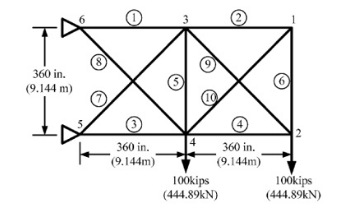

In [1]:
import numpy as np
import copy as cp
import math
import matplotlib.pyplot as plt

## Structure Data Entry

In [2]:
# Constants
E=200*10**9 # N/m^2
A=0.005    # m^2

xFact=50    # Deflection Scale factor

#Nodal Coordinates[x,y] in ascending node order
nodes= np.array([[18.288,9.144],
                 [18.288,0],
                 [9.144,9.144],
                 [9.144,0],
                 [0,0],
                 [0,9.144]])

# Members [node_i,node_j]
members= np.array([[1,2],
                   [2,3],
                   [3,4],
                   [4,5],
                   [1,4],
                   [1,3],
                   [2,4],
                   [3,5],
                   [3,6],
                   [4,6]])

# Supports
restrainedDof= [9,10,11,12]  #The degrees of freedom restrained by supports

# Loading
forceVector= np.array([[0,0,0,-444890,0,0,0,-444890,0,0,0,0]]) #Vector of externally applied loads

#=============================================================End Of Data Entry=================================================================#

## Calculate Member Orientation and Length

In [3]:
# Define a function to calculate member orientation and length
def memberOrientation(memberNo):
    
    memberIndex= memberNo-1      ## Index identifying member in array of numbers
    node_i= members[memberIndex][0]
    node_j= members[memberIndex][1]

    xi= nodes[node_i-1][0]    #x_coordinate of node i
    yi= nodes[node_i-1][1]    #y_coordinate of node i
    xj= nodes[node_j-1][0]    #x_coordinate of node j
    yj= nodes[node_j-1][1]    #y_coordinate of node j

    # Angle of member w.r.to horizontal axis

    dx=xj-xi
    dy=yj-yi
    mag=math.sqrt(dx**2+dy**2) ## magnitude of vector is length of member
    memberVector=np.array([dx,dy])  ## member represented as a vector

    #Need to capture quadrant first then identify appropriate reference axis

    if (dx>0 and dy==0):
        theta=0
    elif (dx==0 and dy>0):
        theta=math.pi/2
    elif (dx<0 and dy==0):
        theta=math.pi
    elif (dx==0 and dy<0):
        theta=3*math.pi/2
    elif (dx>0 and dy>0):
        ## 0<theta<90
        refVector=np.array([1,0]) ## vector describing positive x-axis
        theta=math.acos(refVector.dot(memberVector)/mag)  ## Angle between two vectors
    elif (dx<0 and dy>0):
        ## 90<theta<180
        refVector=np.array([0,1]) 
        theta= (math.pi/2) + math.acos(refVector.dot(memberVector)/mag) 
    elif (dx<0 and dy<0):
        ## 180<theta<270
        refVector=np.array([-1,0]) 
        theta= (math.pi) + math.acos(refVector.dot(memberVector)/mag) 
    else:
        ## 270<theta<360
        refVector=np.array([0,-1]) 
        theta= (3*math.pi/2) + math.acos(refVector.dot(memberVector)/mag) 
           
    return[theta, mag]
        

In [4]:
# Calculate orientation and length for each member and store

orientations= np.array([])   # Initialise an array to hold orientations
lengths=np.array([])

for n, mbr in enumerate(members):
    [angle, length]= memberOrientation(n+1)
    orientations= np.append(orientations, angle)
    lengths = np.append(lengths, length)

print(orientations)
    

[4.71238898 2.35619449 4.71238898 3.14159265 3.92699082 3.14159265
 3.14159265 3.92699082 3.14159265 2.35619449]


## Define a function to calculate member global stiffness matrix

In [5]:
def calKg(memberNo):

    theta= orientations[memberNo-1]
    mag=lengths[memberNo-1]
    c=math.cos(theta)
    s=math.sin(theta)

    K11= (E*A/mag)*np.array([[c**2,c*s],
                   [c*s,s**2]])
    K12= (E*A/mag)*np.array([[-c**2,-c*s],
                   [-c*s,-s**2]])
    K21= (E*A/mag)*np.array([[-c**2,-c*s],
                   [-c*s,-s**2]])
    K22= (E*A/mag)*np.array([[c**2,c*s],
                   [c*s,s**2]])
    return[K11,K12,K21,K22]

## Build The Primary Stiffness Matrix Kp

In [6]:
nDof= np.amax(members)*2   #Total no. of Degrees of freedom
Kp=np.zeros([nDof, nDof])  # Initialising the Primary Stiffness matrix

for n, mbr in enumerate(members):
    [K11,K12,K21,K22]= calKg(n+1)

    node_i=mbr[0]
    node_j=mbr[1]
    ia=2*node_i-2  #index 0
    ib=2*node_i-1  #index 1
    ja=2*node_j-2  #index 2
    jb=2*node_j-1  #index 3

    Kp[ia:ib+1, ia:ib+1]= Kp[ia:ib+1, ia:ib+1] + K11
    Kp[ia:ib+1, ja:jb+1]= Kp[ia:ib+1, ja:jb+1] + K12
    Kp[ja:jb+1, ia:ib+1]= Kp[ja:jb+1, ia:ib+1] + K21
    Kp[ja:jb+1, ja:jb+1]= Kp[ja:jb+1, ja:jb+1] + K22



## Extract Structure Stiffness Matrix

In [7]:
restrainedIndex= [x-1 for x in restrainedDof]

Ks=np.delete(Kp,restrainedIndex,0)
Ks=np.delete(Ks,restrainedIndex,1)
Ks=np.matrix(Ks)

forceVector=  np.array([[0,0,0,-444890,0,0,0,-444890,0,0,0,0]]).T 
ForceVector=np.delete(forceVector,restrainedIndex,0) 
U=Ks.I*ForceVector

In [8]:

UG= np.zeros([nDof,1])
active_dof_counter=0

for d in range(nDof):
    if d in restrainedIndex:
        UG[d,0]=0
    else:
        UG[d,0]=U[active_dof_counter].item()
        active_dof_counter= active_dof_counter+1

for i in range(len(nodes)):
    print(f"Node{i+1}: Ux= {UG[2*i,0]:.6f}m, Uy={UG[2*i+1,0]:.6f}m")

Node1: Ux= 0.009580m, Uy=-0.042886m
Node2: Ux= -0.010760m, Uy=-0.044518m
Node3: Ux= 0.007948m, Uy=-0.018921m
Node4: Ux= -0.008325m, Uy=-0.020364m
Node5: Ux= 0.000000m, Uy=0.000000m
Node6: Ux= 0.000000m, Uy=0.000000m


## Member Forces

In [9]:
memberForces=[]

for n, mbr in enumerate(members):
    node_i= mbr[0]
    node_j= mbr[1]

    theta=orientations[n]
    mag=lengths[n]
    c=math.cos(theta)
    s=math.sin(theta)

    # Gather all 4 global displacements for the particular member
    ug= np.array([[UG[2*node_i-2,0]],   # ui_x
                  [UG[2*node_i-1,0]],   # ui_y
                  [UG[2*node_j-2,0]],   # uj_x
                  [UG[2*node_j-1,0]]    # uj_y
                 ])
    # Transformation matrix
    T=np.array([[c,s,0,0],
                [0,0,c,s]
                ])

    # Converting Global to Local Displacements
    ulocal= np.matmul(T,ug)

    # Extracting Individual Local displacements from matrix
    ui_local= ulocal[0,0].item()
    uj_local= ulocal[1,0].item()

    axial_force= (E*A/mag)*(ui_local-uj_local)
    memberForces.append(axial_force)

    status= "Tension" if axial_force>=0 else "Compression"
    print(f"Member{n+1} (Node {node_i} to {node_j}): {axial_force/1000:.2f} kN({status})")

Member1 (Node 1 to 2): -178.51 kN(Compression)
Member2 (Node 2 to 3): -376.72 kN(Compression)
Member3 (Node 3 to 4): -157.89 kN(Compression)
Member4 (Node 4 to 5): 910.40 kN(Tension)
Member5 (Node 1 to 4): 252.45 kN(Tension)
Member6 (Node 1 to 3): -178.51 kN(Compression)
Member7 (Node 2 to 4): 266.38 kN(Tension)
Member8 (Node 3 to 5): 600.01 kN(Tension)
Member9 (Node 3 to 6): -869.16 kN(Compression)
Member10 (Node 4 to 6): -658.33 kN(Compression)


## Plotting

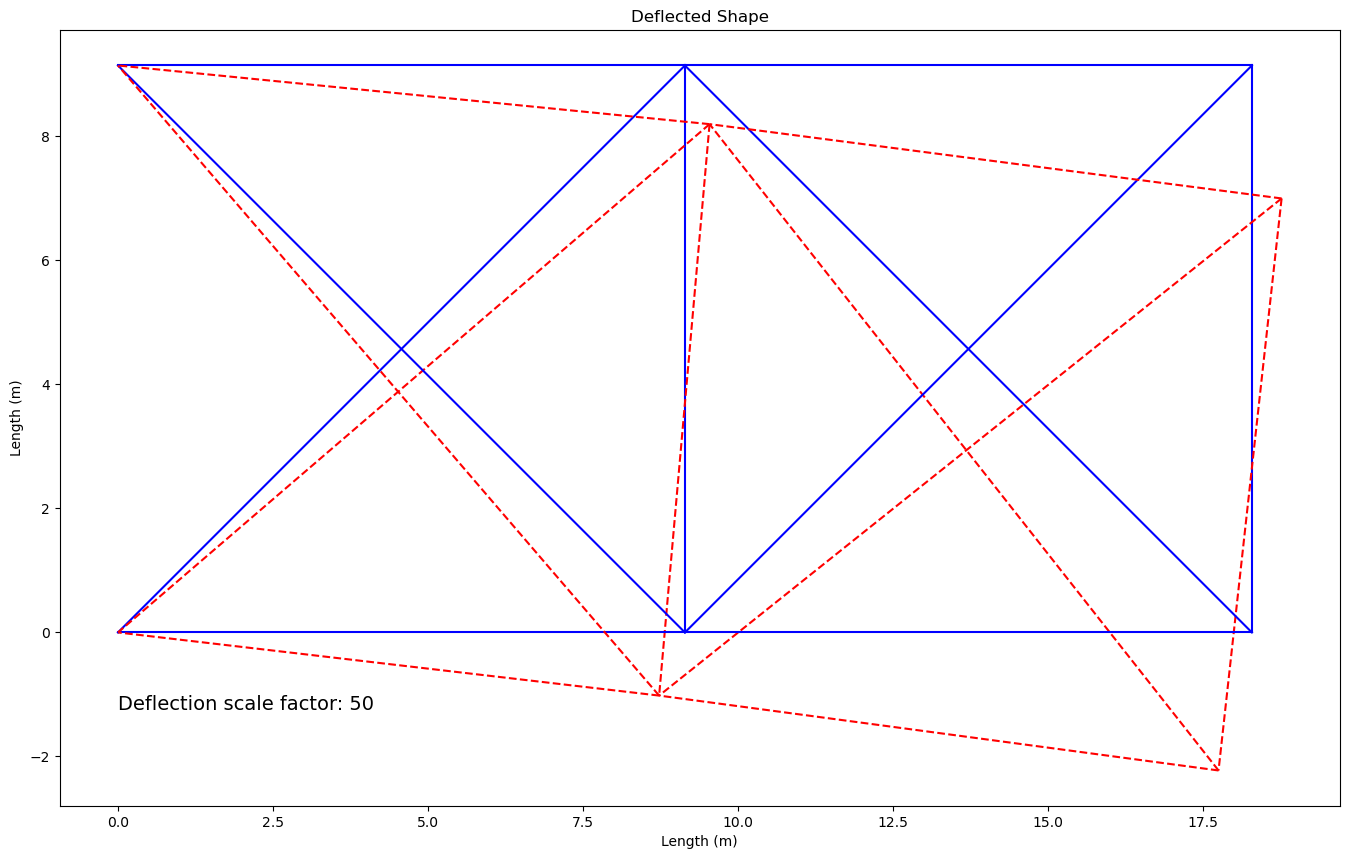

In [12]:
xFact= 50
fig= plt.figure()
axes= fig.add_axes([0.1,0.1,2,2])
fig.gca().set_aspect('equal',adjustable='box')
#Plot original and deformed members 
for n, mbr in enumerate(members):
    node_i= mbr[0]
    node_j= mbr[1]

    # Original positions
    xi,yi= nodes[node_i-1][0], nodes[node_i-1][1]
    xj,yj= nodes[node_j-1][0], nodes[node_j-1][1]

    #Deformed positions
    xi_def= xi+ UG[2*node_i-2,0]* xFact
    yi_def= yi+ UG[2*node_i-1,0]* xFact
    xj_def= xj+ UG[2*node_j-2,0]* xFact
    yj_def= yj+ UG[2*node_j-1,0]* xFact

    axes.plot([xi,xj], [yi,yj],'b')
    axes.plot([xi_def,xj_def],[yi_def,yj_def],'--r')

axes.set_title("Deflected Shape")
axes.set_xlabel("Length (m)")
axes.set_ylabel("Length (m)")
label="Deflection scale factor: " +str(xFact)
plt.text(0,-1, label, fontsize=14,va="top")
plt.show()
   